# ✍️ 실습 2: MNIST 손글씨 숫자 인식 (CNN)
> **AI Programming Course** — Konan Technology

---

## 학습 목표
- MNIST 데이터셋을 로드하고 시각화한다
- CNN(Convolutional Neural Network)을 PyTorch로 설계한다
- `DataLoader`를 사용한 미니배치 학습을 구현한다
- 학습 곡선, Confusion Matrix, Feature Map을 시각화한다

## 실습 구성
| 단계 | 내용 |
|:---:|------|
| 1 | 환경 세팅 및 라이브러리 import |
| 2 | MNIST 데이터 로드 & 시각화 |
| 3 | CNN 모델 정의 (Conv2d, MaxPool, Dropout) |
| 4 | DataLoader & 학습 루프 |
| 5 | 정확도 평가 & 학습 곡선 시각화 |
| 6 | 틀린 예측 분석 & Feature Map 시각화 |
| 7 | ✏️ 도전 과제 |


---
## Step 1: 환경 세팅

In [5]:
import sys, subprocess, matplotlib
import matplotlib.font_manager as fm

if 'google.colab' in sys.modules:
    # Colab: 나눔고딕 설치
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    font_name = 'NanumGothic'
else:
    # 로컬 Windows: Malgun Gothic
    font_name = 'Malgun Gothic'

matplotlib.rcParams['font.family'] = font_name
matplotlib.rcParams['axes.unicode_minus'] = False
print(f'폰트 설정 완료: {font_name}')


폰트 설정 완료: NanumGothic


In [6]:
# !pip install torch torchvision matplotlib seaborn scikit-learn


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 재현성 시드
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device : {device}')


PyTorch: 2.9.0+cu126
Device : cuda


---
## Step 2: MNIST 데이터 로드 & 시각화

> `torchvision.datasets.MNIST`로 자동 다운로드합니다. (~11MB)

**전처리 파이프라인:**
- `ToTensor()`: PIL Image → Tensor `[0,255]` → `[0.0,1.0]`
- `Normalize((0.1307,),(0.3081,))`: MNIST 전체 평균/표준편차로 정규화

In [7]:
# ─── 전처리 정의 ─────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 공식 통계값
])

# ─── 데이터셋 다운로드 & 로드 ─────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f'학습 데이터: {len(train_dataset):,}개')
print(f'테스트 데이터: {len(test_dataset):,}개')
print(f'이미지 크기: {train_dataset[0][0].shape}  (채널×높이×너비)')
print(f'클래스: {train_dataset.classes}')


학습 데이터: 60,000개
테스트 데이터: 10,000개
이미지 크기: torch.Size([1, 28, 28])  (채널×높이×너비)
클래스: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


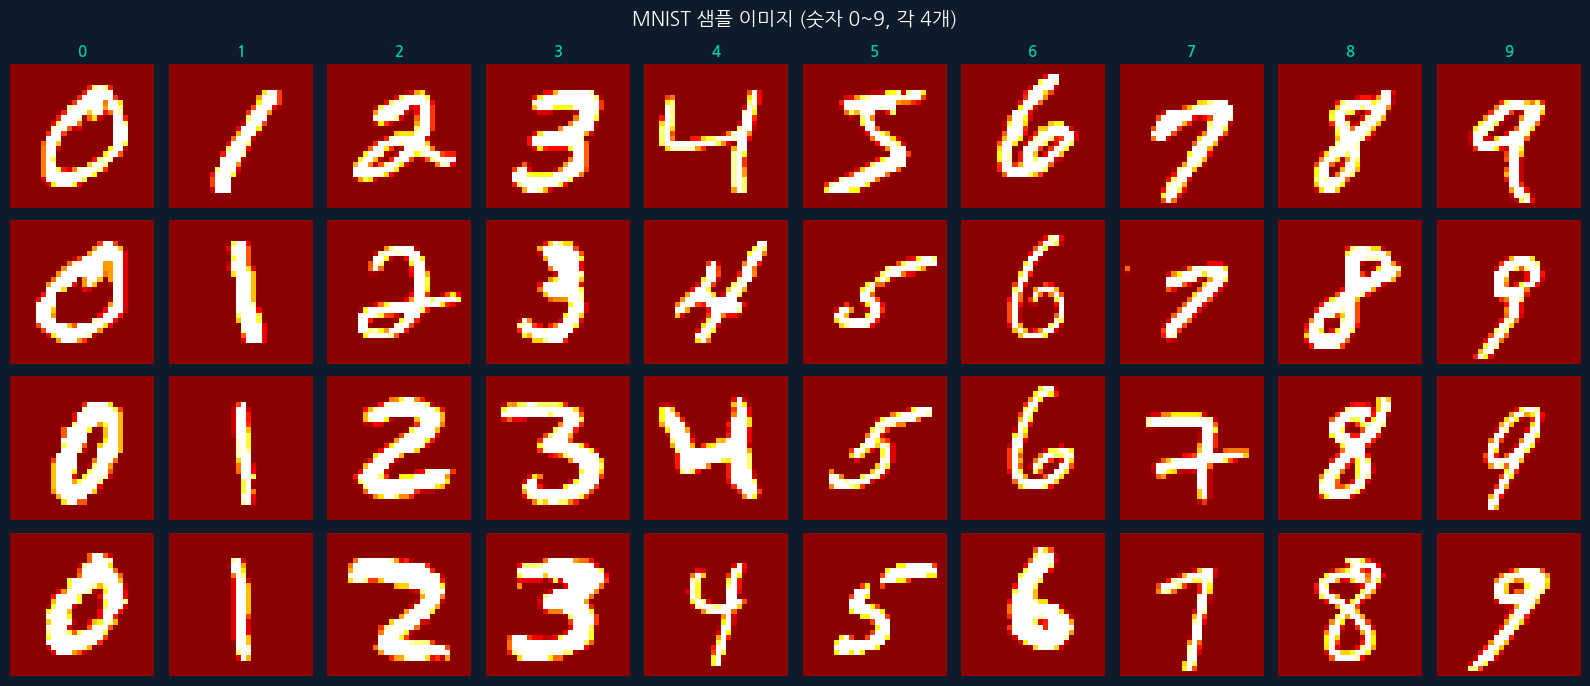

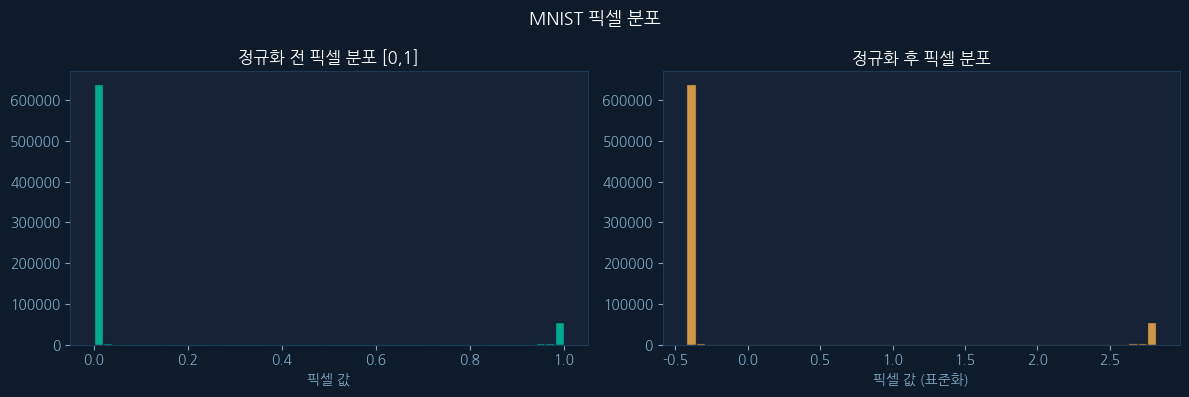

In [8]:
# ─── 샘플 이미지 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
fig.patch.set_facecolor('#0d1b2a')
fig.suptitle('MNIST 샘플 이미지 (숫자 0~9, 각 4개)', color='white', fontsize=14)

# 각 숫자별 샘플 찾기
samples = {i: [] for i in range(10)}
for img, label in train_dataset:
    if len(samples[label]) < 4:
        samples[label].append(img)
    if all(len(v) == 4 for v in samples.values()):
        break

for col, digit in enumerate(range(10)):
    for row in range(4):
        ax = axes[row][col]
        img = samples[digit][row].squeeze().numpy()
        ax.imshow(img, cmap='hot', vmin=-1, vmax=2)
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), color='#00c9a7', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 픽셀 분포 히스토그램
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0d1b2a')
for ax in [ax1, ax2]:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')

# 원본 픽셀값 분포
raw = datasets.MNIST('./data', train=True, download=False,
                     transform=transforms.ToTensor())
pixels_raw = torch.stack([raw[i][0] for i in range(1000)]).numpy().flatten()
ax1.hist(pixels_raw, bins=50, color='#00c9a7', alpha=0.8, edgecolor='#0d1b2a')
ax1.set_title('정규화 전 픽셀 분포 [0,1]', color='white')
ax1.set_xlabel('픽셀 값', color='#7fa8c4')

# 정규화 후 픽셀값 분포
pixels_norm = torch.stack([train_dataset[i][0] for i in range(1000)]).numpy().flatten()
ax2.hist(pixels_norm, bins=50, color='#ffb74d', alpha=0.8, edgecolor='#0d1b2a')
ax2.set_title('정규화 후 픽셀 분포', color='white')
ax2.set_xlabel('픽셀 값 (표준화)', color='#7fa8c4')

plt.suptitle('MNIST 픽셀 분포', color='white', fontsize=13)
plt.tight_layout()
plt.show()


---
## Step 3: CNN 모델 정의

```
Input(1×28×28)
  → Conv2d(1→32, 3×3) → BatchNorm → ReLU → MaxPool(2×2)   → (32×13×13)
  → Conv2d(32→64, 3×3) → BatchNorm → ReLU → MaxPool(2×2)  → (64×5×5)
  → Flatten → FC(1600→128) → Dropout(0.5)
  → FC(128→10)
```

| 레이어 | 역할 |
|--------|------|
| `Conv2d` | 필터로 엣지/곡선 등 공간 특징 추출 |
| `BatchNorm2d` | 학습 안정화, 빠른 수렴 |
| `MaxPool2d` | 공간 크기 축소, 위치 불변성 확보 |
| `Dropout` | 과적합 방지 정규화 |

In [9]:
class MnistCNN(nn.Module):
    """
    MNIST 손글씨 분류를 위한 CNN 모델
    
    Architecture:
        Conv Block 1: Conv(1→32) → BN → ReLU → MaxPool
        Conv Block 2: Conv(32→64) → BN → ReLU → MaxPool
        Classifier:   FC(1600→128) → Dropout → FC(128→10)
    """
    def __init__(self, dropout_rate=0.5):
        super(MnistCNN, self).__init__()

        # ── 합성곱 블록 1 ──────────────────────────────────────────────
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32,
                      kernel_size=3, padding=1),  # 1×28×28 → 32×28×28
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32×28×28 → 32×14×14
        )

        # ── 합성곱 블록 2 ──────────────────────────────────────────────
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, padding=1),  # 32×14×14 → 64×14×14
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64×14×14 → 64×7×7
        )

        # ── 완전연결 분류기 ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),             # 64×7×7 = 3136
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)   # Conv Block 1
        x = self.conv_block2(x)   # Conv Block 2
        x = self.classifier(x)   # Classifier
        return x                  # raw logits (CrossEntropyLoss 사용)

    def get_feature_maps(self, x):
        """Feature Map 시각화를 위해 중간 출력 반환"""
        feat1 = self.conv_block1(x)
        feat2 = self.conv_block2(feat1)
        return feat1, feat2


model = MnistCNN(dropout_rate=0.5).to(device)
print(model)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n총 파라미터 : {total_params:,}개')
print(f'학습 파라미터: {train_params:,}개')


MnistCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

총 파라미터 : 421,834개
학습 파라미터: 421,834개


In [10]:
# ─── 각 레이어의 출력 크기 확인 ──────────────────────────────────────────
dummy = torch.zeros(1, 1, 28, 28).to(device)
print('레이어별 출력 크기 추적:')
print(f'  Input         : {dummy.shape}')
out1 = model.conv_block1(dummy)
print(f'  Conv Block 1  : {out1.shape}')
out2 = model.conv_block2(out1)
print(f'  Conv Block 2  : {out2.shape}')
flat = out2.view(1, -1)
print(f'  Flatten       : {flat.shape}')
out_final = model(dummy)
print(f'  Output (logits): {out_final.shape}')


레이어별 출력 크기 추적:
  Input         : torch.Size([1, 1, 28, 28])
  Conv Block 1  : torch.Size([1, 32, 14, 14])
  Conv Block 2  : torch.Size([1, 64, 7, 7])
  Flatten       : torch.Size([1, 3136])
  Output (logits): torch.Size([1, 10])


---
## Step 4: DataLoader 및 학습 루프

> **미니배치(Mini-batch) 학습**: 전체 데이터를 `batch_size` 단위로 나눠
> 각 배치마다 가중치를 업데이트합니다. 1 Epoch = 전체 데이터를 한 번 순회.

In [11]:
# ─── DataLoader ──────────────────────────────────────────────────────────
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'배치 크기: {BATCH_SIZE}')
print(f'학습 배치 수: {len(train_loader)}')
print(f'테스트 배치 수: {len(test_loader)}')

# 첫 배치 확인
images, labels = next(iter(train_loader))
print(f'\n첫 배치 이미지 형태: {images.shape}  (배치×채널×높이×너비)')
print(f'첫 배치 레이블 형태: {labels.shape}')


배치 크기: 64
학습 배치 수: 938
테스트 배치 수: 157

첫 배치 이미지 형태: torch.Size([64, 1, 28, 28])  (배치×채널×높이×너비)
첫 배치 레이블 형태: torch.Size([64])


In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    """1 에폭 학습 함수."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """평가 함수. (그래디언트 계산 없음)"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


In [13]:
# ─── 하이퍼파라미터 ───────────────────────────────────────────────────────
NUM_EPOCHS    = 15
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# 학습률 스케줄러: 5 epoch마다 lr × 0.5
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print(f'학습 시작 (Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, lr: {LEARNING_RATE})')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>9} | {"Test Acc":>8} | {"LR":>8}')
print('-' * 65)

best_test_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)

    # 최고 정확도 모델 저장
    if te_acc > best_test_acc:
        best_test_acc = te_acc
        torch.save(model.state_dict(), 'mnist_cnn_best.pth')
        mark = ' ⭐'
    else:
        mark = ''

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | '
          f'{te_loss:>9.4f} | {te_acc*100:>7.2f}%{mark} | {current_lr:.6f}')

print(f'\n✅ 학습 완료!  최고 Test Accuracy: {best_test_acc*100:.2f}%')


학습 시작 (Epochs: 15, Batch: 64, lr: 0.001)
 Epoch | Train Loss | Train Acc | Test Loss | Test Acc |       LR
-----------------------------------------------------------------
     1 |     0.2517 |    92.28% |    0.0491 |   98.42% ⭐ | 0.001000
     2 |     0.1190 |    96.30% |    0.0348 |   98.91% ⭐ | 0.001000
     3 |     0.0996 |    96.95% |    0.0366 |   98.83% | 0.001000
     4 |     0.0853 |    97.40% |    0.0345 |   98.83% | 0.001000
     5 |     0.0766 |    97.59% |    0.0271 |   99.17% ⭐ | 0.000500
     6 |     0.0564 |    98.23% |    0.0268 |   99.11% | 0.000500
     7 |     0.0515 |    98.30% |    0.0274 |   99.10% | 0.000500
     8 |     0.0441 |    98.61% |    0.0261 |   99.16% | 0.000500
     9 |     0.0417 |    98.59% |    0.0263 |   99.25% ⭐ | 0.000500
    10 |     0.0410 |    98.65% |    0.0271 |   99.21% | 0.000250
    11 |     0.0314 |    98.98% |    0.0250 |   99.27% ⭐ | 0.000250
    12 |     0.0280 |    99.07% |    0.0246 |   99.27% | 0.000250
    13 |     0.0271 |    

---
## Step 5: 학습 곡선 시각화

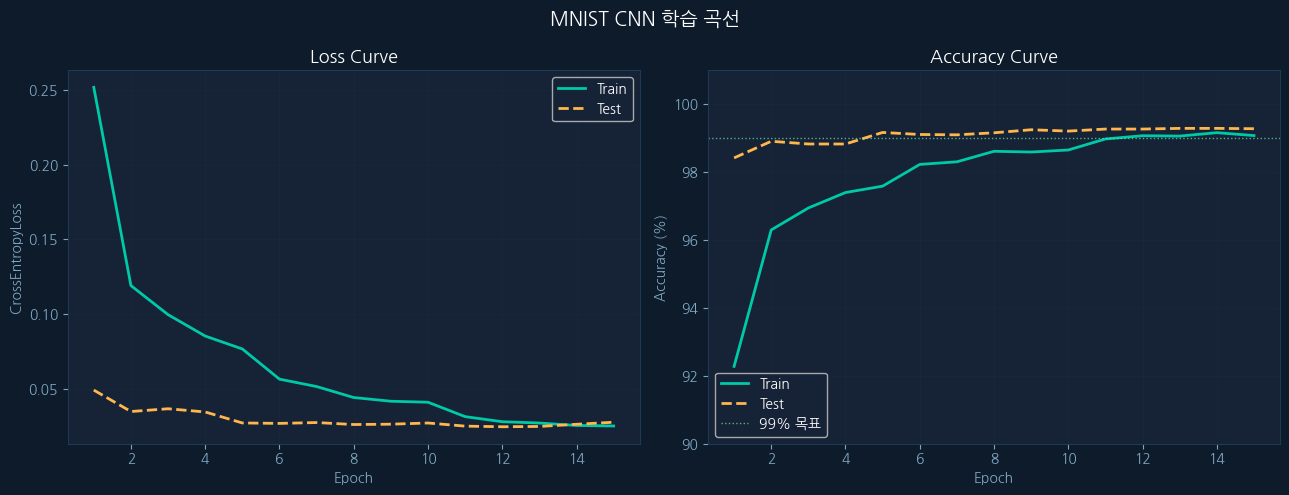

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d1b2a')
epochs = range(1, NUM_EPOCHS + 1)

for ax in axes:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    ax.set_xlabel('Epoch', color='#7fa8c4')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# 손실 곡선
axes[0].plot(epochs, history['train_loss'], color='#00c9a7', lw=2, label='Train')
axes[0].plot(epochs, history['test_loss'],  color='#ffb74d', lw=2, label='Test', linestyle='--')
axes[0].set_title('Loss Curve', color='white', fontsize=13)
axes[0].set_ylabel('CrossEntropyLoss', color='#7fa8c4')
axes[0].legend(facecolor='#162236', labelcolor='white')

# 정확도 곡선
axes[1].plot(epochs, [a*100 for a in history['train_acc']], color='#00c9a7', lw=2, label='Train')
axes[1].plot(epochs, [a*100 for a in history['test_acc']],  color='#ffb74d', lw=2, label='Test', linestyle='--')
axes[1].axhline(y=99, color='#69f0ae', lw=1, linestyle=':', alpha=0.7, label='99% 목표')
axes[1].set_title('Accuracy Curve', color='white', fontsize=13)
axes[1].set_ylabel('Accuracy (%)', color='#7fa8c4')
axes[1].set_ylim(90, 101)
axes[1].legend(facecolor='#162236', labelcolor='white')

plt.suptitle('MNIST CNN 학습 곡선', color='white', fontsize=14)
plt.tight_layout()
plt.show()


---
## Step 6: 결과 분석 및 시각화

### 6-1. Confusion Matrix

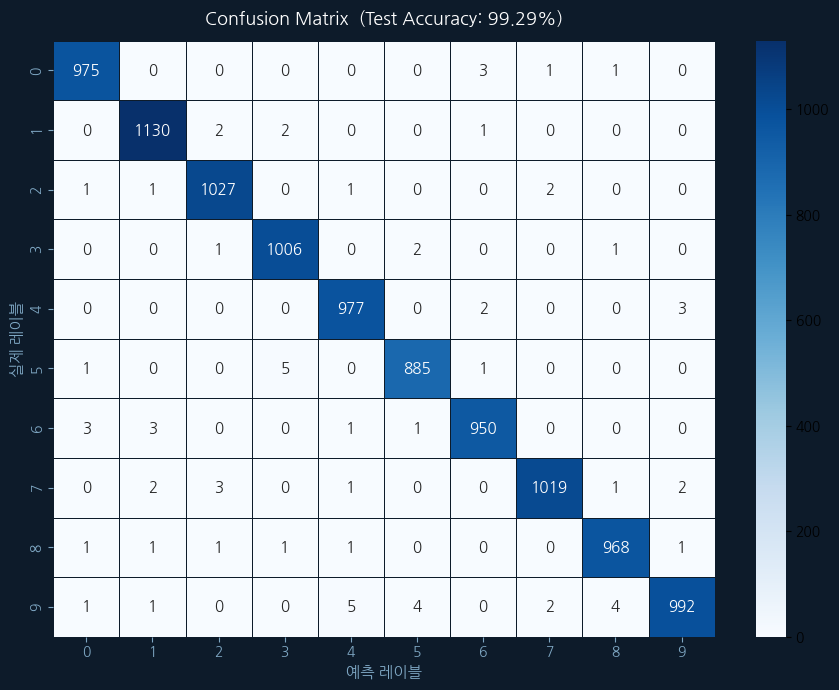

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [15]:
# ─── 최고 모델 로드 후 최종 평가 ─────────────────────────────────────────
model.load_state_dict(torch.load('mnist_cnn_best.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)
final_acc = (y_pred == y_true).mean()

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            ax=ax, linewidths=0.5, linecolor='#0d1b2a',
            annot_kws={'size':11})
ax.set_title(f'Confusion Matrix  (Test Accuracy: {final_acc*100:.2f}%)',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('예측 레이블', color='#7fa8c4', fontsize=11)
ax.set_ylabel('실제 레이블', color='#7fa8c4', fontsize=11)
ax.tick_params(colors='#7fa8c4')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))


### 6-2. 틀린 예측 시각화

전체 오분류 샘플: 70개 / 10,000개


/tmp/ipython-input-3254097799.py:36: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


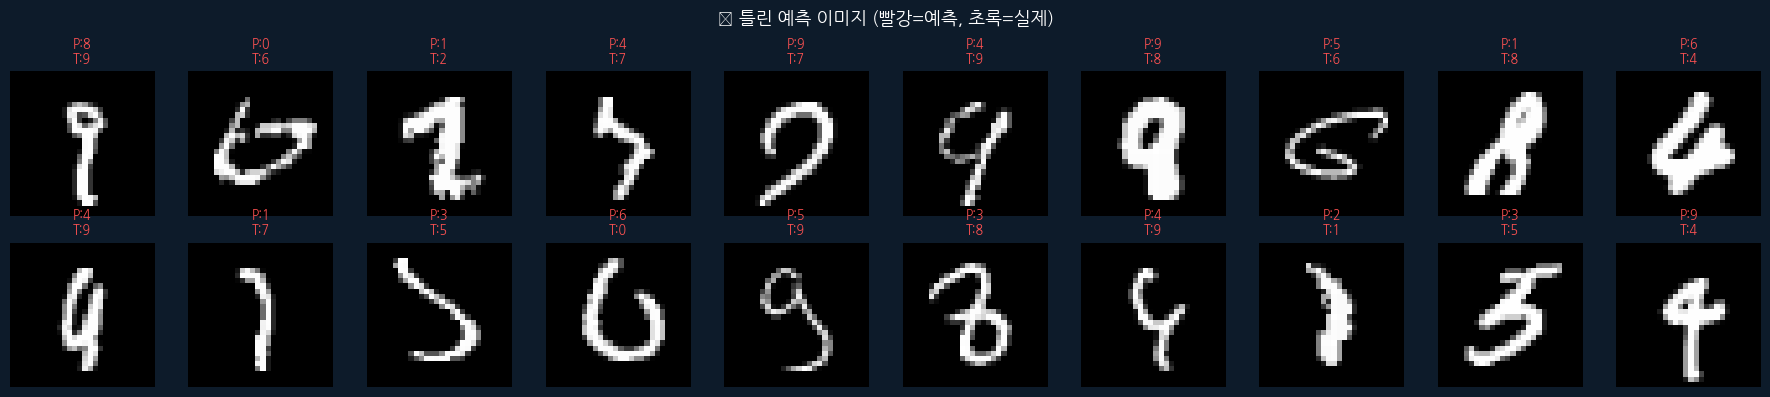

In [16]:
# ─── 틀린 예측 이미지 수집 ───────────────────────────────────────────────
wrong_images, wrong_preds, wrong_labels = [], [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        mask = (predicted != labels.to(device))
        wrong_images.extend(images[mask].cpu())
        wrong_preds.extend(predicted[mask].cpu().numpy())
        wrong_labels.extend(labels[mask.cpu()].numpy())
        if len(wrong_images) >= 20:
            break

print(f'전체 오분류 샘플: {int((1-final_acc)*10000)}개 / 10,000개')

# 시각화
n_show = min(20, len(wrong_images))
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.patch.set_facecolor('#0d1b2a')
fig.suptitle('❌ 틀린 예측 이미지 (빨강=예측, 초록=실제)', color='white', fontsize=13)

for i in range(n_show):
    ax = axes[i//10][i%10]
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f'P:{wrong_preds[i]}\nT:{wrong_labels[i]}',
                 color='#ff5252', fontsize=9)
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor('#ff5252')
        sp.set_linewidth(2)
        sp.set_visible(True)

plt.tight_layout()
plt.show()


### 6-3. Feature Map 시각화

> CNN이 이미지를 보는 방식: 각 필터가 어떤 특징을 감지하는지 확인합니다.

입력 이미지 레이블: 7
Conv Block 1 Feature Map: torch.Size([1, 32, 14, 14])  → 32채널 × 14×14
Conv Block 2 Feature Map: torch.Size([1, 64, 7, 7])  → 64채널 × 7×7


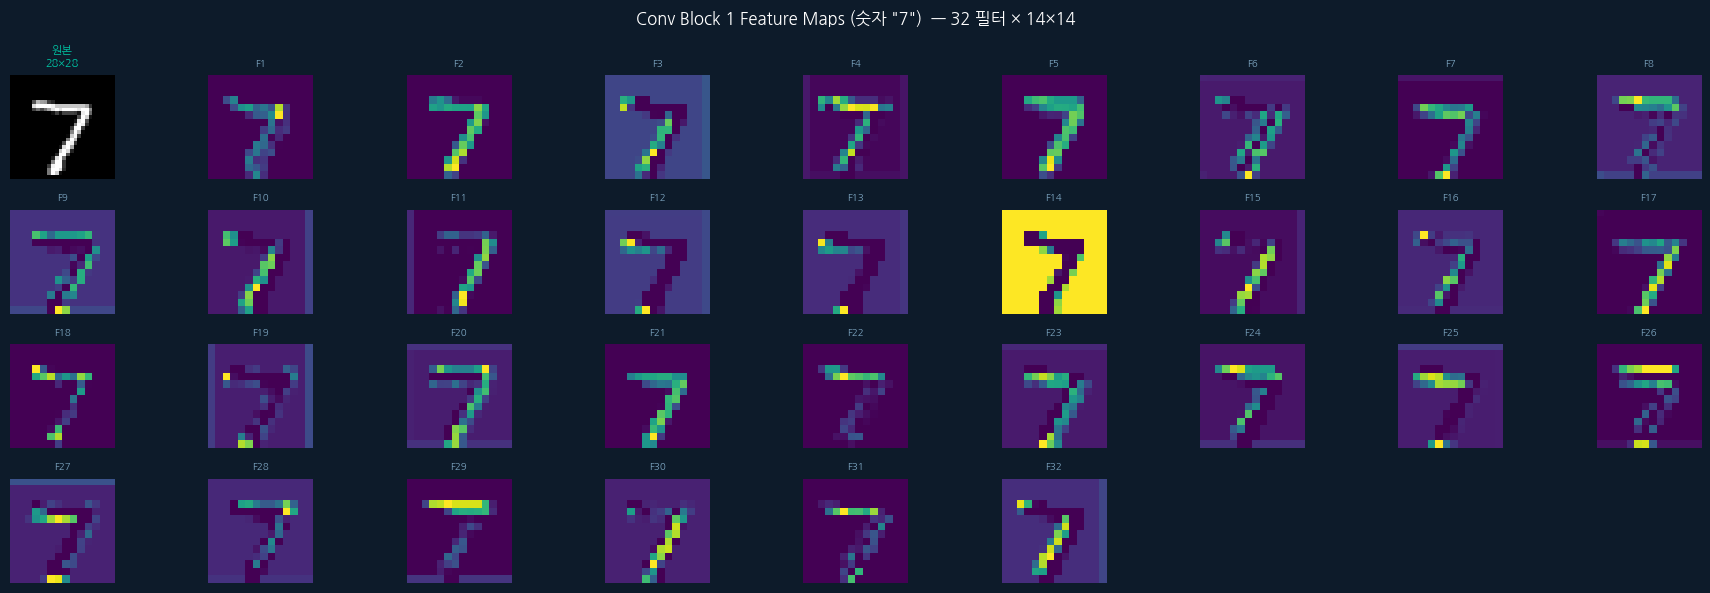

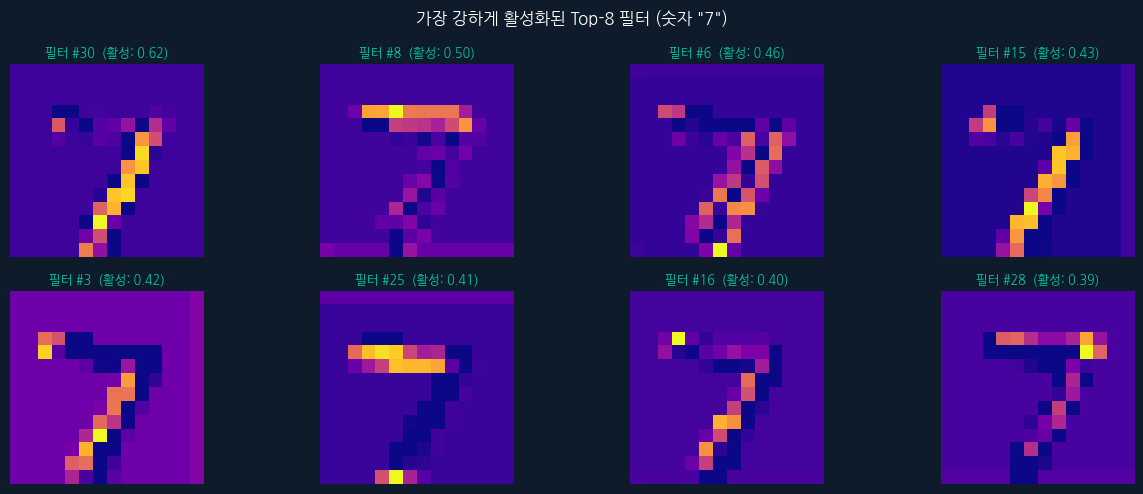

In [17]:
# ─── 테스트 이미지 1개 선택 ───────────────────────────────────────────────
sample_img, sample_label = test_dataset[0]
x = sample_img.unsqueeze(0).to(device)  # (1,1,28,28)

model.eval()
with torch.no_grad():
    feat1, feat2 = model.get_feature_maps(x)

print(f'입력 이미지 레이블: {sample_label}')
print(f'Conv Block 1 Feature Map: {feat1.shape}  → 32채널 × 14×14')
print(f'Conv Block 2 Feature Map: {feat2.shape}  → 64채널 × 7×7')

# ─── Conv Block 1 Feature Map (32개 필터) ────────────────────────────────
fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('#0d1b2a')
fig.suptitle(f'Conv Block 1 Feature Maps (숫자 "{sample_label}")  — 32 필터 × 14×14',
             color='white', fontsize=12)

# 원본 이미지
ax0 = fig.add_subplot(4, 9, 1)
ax0.imshow(sample_img.squeeze(), cmap='gray')
ax0.set_title('원본\n28×28', color='#00c9a7', fontsize=8)
ax0.axis('off')

# 각 필터의 특징 맵
for i in range(32):
    ax = fig.add_subplot(4, 9, i + 2)
    fm = feat1[0, i].cpu().numpy()
    ax.imshow(fm, cmap='viridis')
    ax.set_title(f'F{i+1}', color='#7fa8c4', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ─── 활성화 크기별 Top-8 필터 ────────────────────────────────────────────
activations = feat1[0].cpu().numpy()
mean_act = activations.mean(axis=(1,2))
top8_idx = np.argsort(mean_act)[::-1][:8]

fig, axes = plt.subplots(2, 4, figsize=(13, 5))
fig.patch.set_facecolor('#0d1b2a')
fig.suptitle(f'가장 강하게 활성화된 Top-8 필터 (숫자 "{sample_label}")', color='white', fontsize=12)
for i, idx in enumerate(top8_idx):
    ax = axes[i//4][i%4]
    fm = activations[idx]
    ax.imshow(fm, cmap='plasma')
    ax.set_title(f'필터 #{idx+1}  (활성: {mean_act[idx]:.2f})', color='#00c9a7', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


---
## ✏️ Step 7: 도전 과제

### 🟢 기초
1. `batch_size`를 32, 128로 바꿔서 학습 속도와 정확도를 비교해보세요.
2. `Dropout` 비율을 0.3, 0.7로 변경해보세요. 과적합이 줄어드나요?

### 🟡 중급
3. Conv Layer를 하나 더 추가해보세요 (64→128 채널).
4. `BatchNorm2d`를 제거했을 때 학습이 어떻게 달라지나요?
5. 데이터 증강 (`RandomRotation`, `RandomAffine`)을 추가해보세요.

### 🔴 심화
6. 7-Segment 모델과 MNIST 모델의 정확도를 같은 그래프에 그려 비교하세요.
7. `torch.onnx.export()`로 모델을 ONNX 형식으로 저장해보세요.
8. Fashion-MNIST로 같은 모델을 학습하면 정확도가 어떻게 되나요?

In [ ]:
# ✏️ 여기에 도전 과제 코드를 작성하세요!

# 예시: Fashion-MNIST 로드
# fashion_train = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
# fashion_test  = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
# ... (동일한 모델 구조로 학습)

print('도전 과제를 직접 구현해보세요! 🚀')


---
## 📝 정리

| 항목 | 7-Segment MLP | MNIST CNN |
|------|:---:|:---:|
| 입력 | 7 (이진 벡터) | 784 (28×28 픽셀) |
| 모델 | MLP 3층 | CNN (Conv×2 + FC×2) |
| 파라미터 | ~500 | ~216,000 |
| 기대 정확도 | ~100% | ~99% |
| 핵심 개념 | 분류 기초, CrossEntropy | 공간 특징, Dropout |

### 다음 단계
- **Transfer Learning**: ResNet, VGG 사전학습 모델 활용
- **Data Augmentation**: 실제 데이터 다양성 확보
- **Model Deployment**: ONNX, TorchScript, FastAPI 서빙
